In [ ]:
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

In [ ]:
X, y = make_moons(n_samples=1000, noise=0.15, random_state=42)
y=y.reshape(-1,1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train = (X_train-mean)/std
X_test = (X_test-mean)/std

In [ ]:
np.random.seed(42)
W1 = np.random.randn(2, 32) * np.sqrt(2 / 2)
b1 = np.zeros((1, 32))
W2 = np.random.randn(32, 16) * np.sqrt(2 / 32)
b2 = np.zeros((1, 16))
W3 = np.random.randn(16, 8) * np.sqrt(2 / 16)
b3 = np.zeros((1, 8))
W4 = np.random.randn(8, 1) * np.sqrt(2 / 8)
b4 = np.zeros((1, 1))

In [ ]:
def relu(Z):
    return np.maximum(0, Z)

def relu_derivative(Z):
    return (Z > 0).astype(float)
def sigmoid(Z):
  Z=np.clip(Z, -500, 500)
  return 1/(1+np.exp(-Z))

In [ ]:
def forward_propagation(X,W1,b1,W2,b2,W3,b3,W4,b4):
  Z1=X @ W1 + b1
  A1 = relu(Z1)

  Z2=A1 @ W2 + b2
  A2=relu(Z2)

  Z3 = A2 @ W3 + b3
  A3 = relu(Z3)

  Z4 = A3 @ W4 + b4
  A4 = sigmoid(Z4)

  cache = {
    "Z1": Z1,
    "A1": A1,
    "Z2": Z2,
    "A2": A2,
    "Z3": Z3,
    "A3": A3,
    "Z4": Z4,
    "A4": A4
  }

  return A4, cache


In [ ]:
def binary_ce(y, y_hat):
  m=y.shape[0]
  val=1e-8
  y_hat=np.clip(y_hat, val, 1-val)
  loss=-(1/m)*np.sum(y*np.log(y_hat)+(1-y)*np.log(1-y_hat))
  return loss

In [ ]:
def back_prop(X,y,cache,W2,W3,W4):
  m=X.shape[0]
  Z1 = cache["Z1"]
  A1 = cache["A1"]
  Z2 = cache["Z2"]
  A2 = cache["A2"]
  Z3 = cache["Z3"]
  A3 = cache["A3"]
  A4 = cache["A4"]

  #output layer
  dZ4=A4-y
  dW4=(1/m)*(A3.T@dZ4)
  db4=(1/m)*np.sum(dZ4,axis=0,keepdims=True)

  #hidden layer 3
  dA3=dZ4@W4.T
  dZ3=dA3*relu_derivative(Z3)
  dW3=(1/m)*(A2.T@dZ3)
  db3=(1/m)*np.sum(dZ3,axis=0,keepdims=True)

  #hidden layer 2
  dA2=dZ3@W3.T
  dZ2=dA2*relu_derivative(Z2)
  dW2=(1/m)*(A1.T@dZ2)
  db2=(1/m)*np.sum(dZ2,axis=0,keepdims=True)

  #hidden layer 1
  dA1 = dZ2 @ W2.T
  dZ1 = dA1 * relu_derivative(Z1)
  dW1 = (1/m) * (X.T @ dZ1)
  db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)

  gradients={
        "dW4": dW4,
        "db4": db4,
        "dW3": dW3,
        "db3": db3,
        "dW2": dW2,
        "db2": db2,
        "dW1": dW1,
        "db1": db1,
  }

  return gradients




In [ ]:
def update_params(W1,b1,W2,b2,W3,b3,W4,b4,gradients,learning_rate):
  W1-=learning_rate*gradients["dW1"]
  b1-=learning_rate*gradients["db1"]
  W2-=learning_rate*gradients["dW2"]
  b2-=learning_rate*gradients["db2"]
  W3-=learning_rate*gradients["dW3"]
  b3-=learning_rate*gradients["db3"]
  W4-=learning_rate*gradients["dW4"]
  b4-=learning_rate*gradients["db4"]

  return W1,b1,W2,b2,W3,b3,W4,b4

In [ ]:
epochs=5000
learning_rate=0.01
loss_history=[]

for epoch in range(epochs):
  y_hat, cache = forward_propagation(X_train,W1,b1,W2,b2,W3,b3,W4,b4)
  loss = binary_ce(y_train, y_hat)
  loss_history.append(loss)
  gradients = back_prop(X_train,y_train,cache,W2,W3,W4)
  W1,b1,W2,b2,W3,b3,W4,b4 = update_params(W1,b1,W2,b2,W3,b3,W4,b4,gradients,learning_rate)

  if epoch%500==0:
    print(f"Loss: {loss:.4f}")
    print(f"Epoch: {epoch}")

Loss: 0.8029
Epoch: 0
Loss: 0.2552
Epoch: 500
Loss: 0.1877
Epoch: 1000
Loss: 0.1194
Epoch: 1500
Loss: 0.0735
Epoch: 2000
Loss: 0.0512
Epoch: 2500
Loss: 0.0395
Epoch: 3000
Loss: 0.0328
Epoch: 3500
Loss: 0.0282
Epoch: 4000
Loss: 0.0250
Epoch: 4500


In [ ]:
def predict(X,W1,b1,W2,b2,W3,b3,W4,b4):
  probabilities,_ = forward_propagation(X,W1,b1,W2,b2,W3,b3,W4,b4)
  prediction = (probabilities>=0.5).astype('int')

  return prediction

In [ ]:
training_predictions = predict(X_train,W1,b1,W2,b2,W3,b3,W4,b4)
#training_predictions = [1,0,1,1]
#y_train = [1,0,0,1]
training_accuracy = np.mean(training_predictions == y_train)*100
print(f"Training Accuracy: %{training_accuracy:.2f}")

testing_predictions = predict(X_test,W1,b1,W2,b2,W3,b3,W4,b4)
testing_accuracy = np.mean(testing_predictions == y_test)*100
print(f"Testing Accuracy: %{testing_accuracy:.2f}")

Training Accuracy: %99.50
Testing Accuracy: %99.50


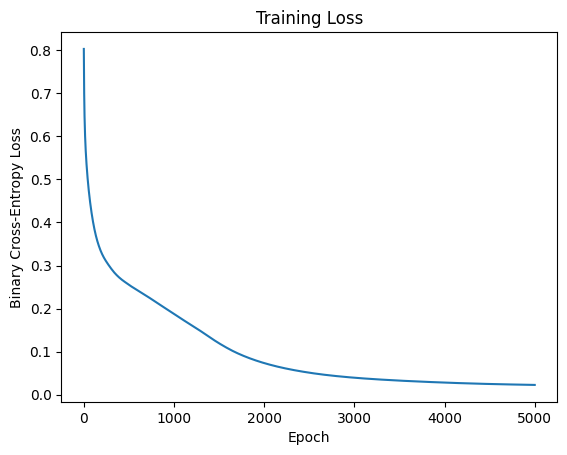

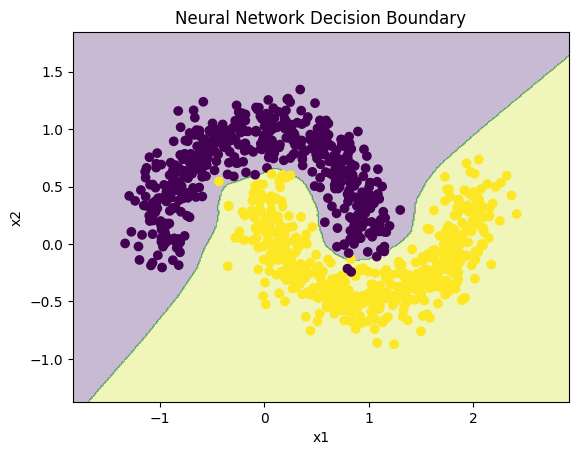

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Training Loss")
plt.show()

x1_min=X[:, 0].min() - 0.5
x1_max=X[:, 0].max() + 0.5
x2_min=X[:, 1].min() - 0.5
x2_max=X[:, 1].max() + 0.5

xx1, xx2=np.meshgrid(np.linspace(x1_min, x1_max, 400),np.linspace(x2_min, x2_max, 400))
grid_points=np.c_[xx1.ravel(),xx2.ravel()]
grid_points_scaled=(grid_points - mean) / std
grid_predictions=predict(grid_points_scaled,W1,b1,W2,b2,W3,b3,W4,b4)
grid_predictions=grid_predictions.reshape(xx1.shape)

plt.figure()
plt.contourf(xx1,xx2,grid_predictions,alpha=0.3)
plt.scatter(X[:, 0],X[:, 1],c=y.ravel())
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Neural Network Decision Boundary")
plt.show()
